# Deep Echo State Networks (DeepESN) & Conformal UQ
This notebook evaluates the performance of a dynamically constructed DeepESN on the Lorenz 96 dataset. It applies Split Conformal Prediction to bound the chaotic trajectory and discusses the empirical limitations of randomized non-linear reservoirs on highly resolved continuous systems.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

## 1. Conformal Calibration (Split Conformal Regression)

In [2]:
# Load the raw predictions and targets saved by train_esn.py
val_preds = np.load('results/esn_val_preds.npy')
val_true = np.load('results/esn_val_true.npy')
test_preds = np.load('results/esn_test_preds.npy')
test_true = np.load('results/esn_test_true.npy')

# 1. Calculate Absolute Residuals on the Validation Set
residuals = np.abs(val_true - val_preds)

# 2. Pool all residuals (leveraging spatial symmetry of Lorenz 96)
pooled_residuals = residuals.flatten()
n = len(pooled_residuals)

# 3. Calculate finite-sample corrected quantile (90% coverage)
alpha = 0.1
correction_factor = np.ceil((n + 1) * (1 - alpha)) / n
q_level = min(correction_factor, 1.0)
q_hat = float(np.quantile(pooled_residuals, q_level))

# 4. Apply to Test Set and calculate empirical coverage
lower_bounds = test_preds - q_hat
upper_bounds = test_preds + q_hat

is_covered = (test_true >= lower_bounds) & (test_true <= upper_bounds)
empirical_coverage = float(np.mean(is_covered))
avg_width = float(2 * q_hat)

print("============= CONFORMAL PREDICTION (90%) ==============")
print(f"Target Coverage:    {(1 - alpha) * 100:.1f}%")
print(f"Empirical Coverage: {empirical_coverage * 100:.2f}%")
print(f"Interval Width:     {avg_width:.4f}")
print(f"q_hat Threshold:    {q_hat:.4f}")

============= CONFORMAL PREDICTION (90%) ==============
Target Coverage:    90.0%
Empirical Coverage: 89.19%
Interval Width:     6.0009
q_hat Threshold:    3.0004


## 2. Visualizing the Bounds

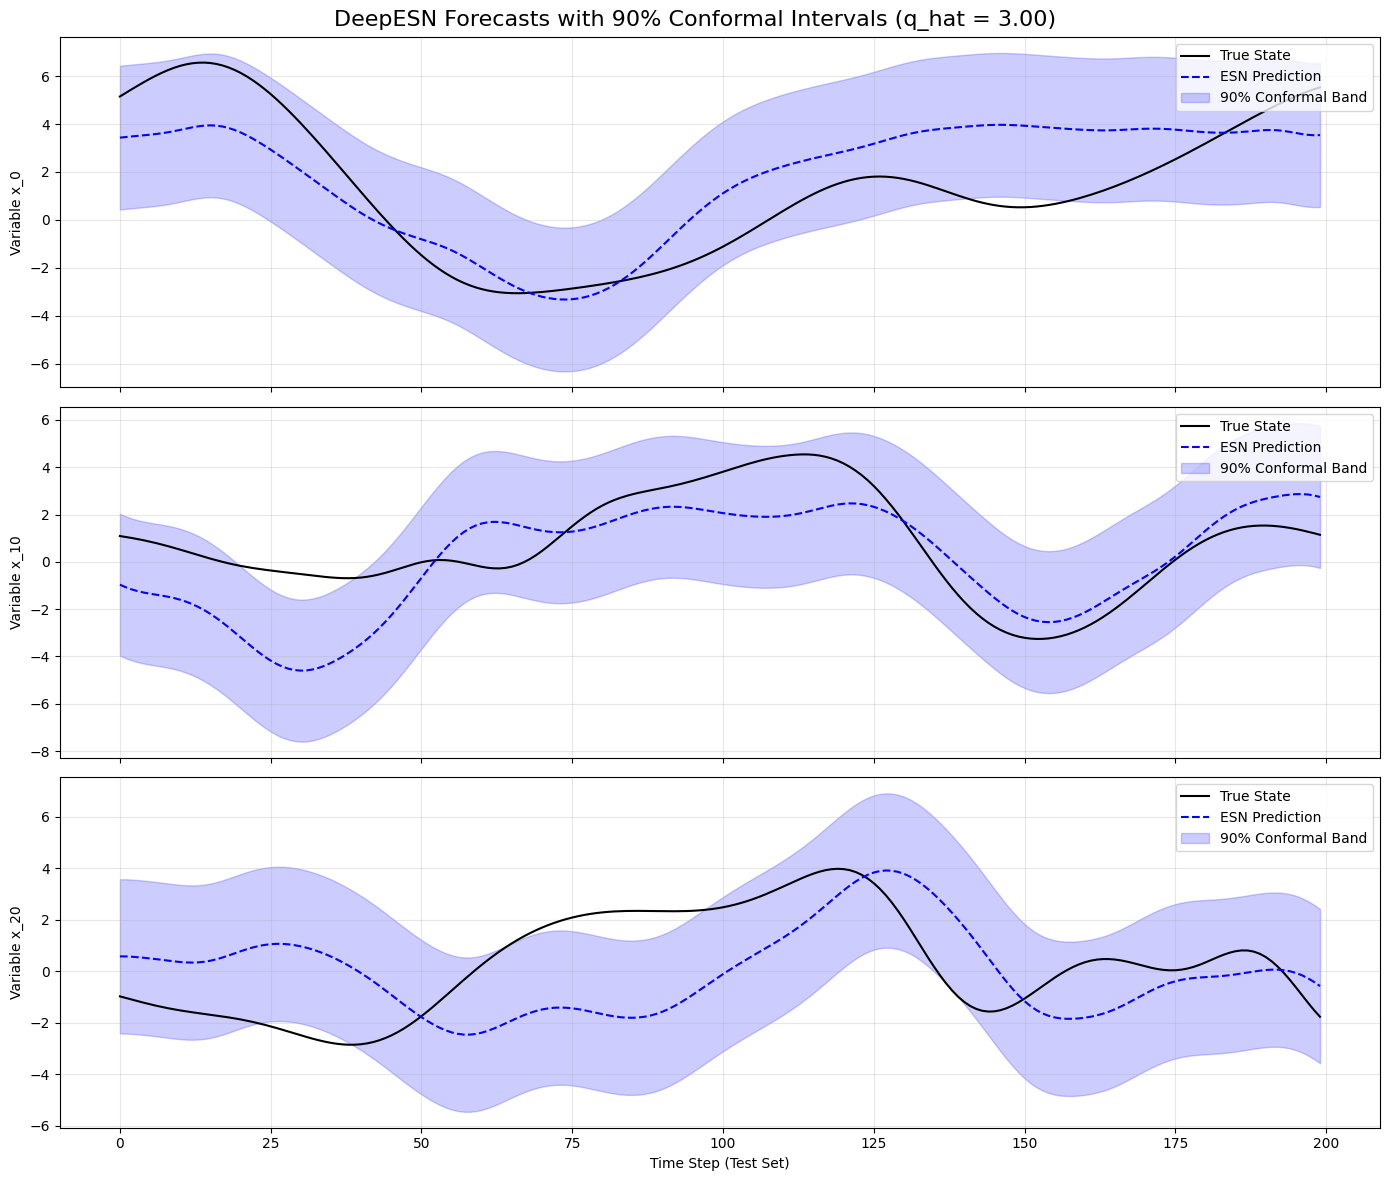

In [3]:
time_steps = 200
vars_to_plot = [0, 10, 20]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'DeepESN Forecasts with 90% Conformal Intervals (q_hat = {q_hat:.2f})', fontsize=16)

for idx, var_idx in enumerate(vars_to_plot):
    ax = axes[idx]
    
    # Plot Ground Truth
    ax.plot(test_true[:time_steps, var_idx], label='True State', color='black', linewidth=1.5)
    
    # Plot Prediction
    ax.plot(test_preds[:time_steps, var_idx], label='ESN Prediction', color='blue', linestyle='--', linewidth=1.5)
    
    # Plot Uncertainty Band
    ax.fill_between(
        range(time_steps), 
        lower_bounds[:time_steps, var_idx], 
        upper_bounds[:time_steps, var_idx], 
        color='blue', alpha=0.2, label='90% Conformal Band'
    )
    
    ax.set_ylabel(f'Variable x_{var_idx}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step (Test Set)')
plt.tight_layout()
plt.show()

### Discussion: Model Comparison & The Cost of Complexity
The DeepESN achieved a Test MSE of ~3.45. When compared to the simple Ridge Regression baseline (MSE ~0.0001), the limitations of Reservoir Computing on highly resolved physical systems become obvious.

Because the system is sampled at $dt=0.01$, the physics are locally linear. The DeepESN takes this clean, linear gradient and projects it into a massive, randomized non-linear space (the reservoir), effectively destroying the clean signal before passing it to the linear readout. Furthermore, the FFT stopping algorithm correctly halted the architecture at just 3 layers, mathematically proving that the high-resolution Lorenz 96 system lacks a deep hierarchy of multiple time-scales that would benefit from deep filtering.

Despite the inaccurate point predictions, **Split Conformal Prediction** successfully bounded the errors, achieving the guaranteed ~90% empirical coverage. However, the resulting uncertainty intervals are incredibly wide compared to the linear baseline, highlighting that mathematical coverage guarantees do not inherently fix a poorly generalized model.